#  Example: Risk-Aware Binary Bernoulli Bandit Ticker Picker Problem
In this example, we implement ε-greedy sampling to solve a binary Bernoulli bandit problem for selecting stock tickers based on their ability to outperform a risk-free investment.

> __Learning Objectives:__
> 
> By the end of this example, you will be able to:
> * __Construct bandit models and world models for ticker selection:__ Build ε-greedy bandit model instances with success/failure counters for each ticker, implement world functions that return binary rewards based on wealth comparisons, and configure parameters controlling exploration versus exploitation tradeoffs.
> * __Train bandit agents using historical market data:__ Sample bandit models iteratively over trading horizons to update Beta distributions representing beliefs about ticker performance, visualize evolution of agent beliefs from uniform initial distributions to data-informed final distributions, and interpret probability density functions for ticker preferences.
> * __Aggregate multi-agent preferences into collective recommendations:__ Generate rankings from multiple independent agents, compute frequencies of tickers appearing in top-M groups across agent populations, and construct preference tables showing probability and ordinal rank for each ticker based on collective agent beliefs.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include-informs.jl")); # include the Include.jl file

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl). 

### Data
We gathered a daily open-high-low-close dataset for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for a few exchange-traded funds and volatility products during that time.

Let's load the dataset by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet).

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"] # load the original dataset (training)

Dict{String, DataFrame} with 515 entries:
  "DD"   => 2329×8 DataFrame…
  "EMR"  => 2767×8 DataFrame…
  "CTAS" => 2767×8 DataFrame…
  "HSIC" => 2767×8 DataFrame…
  "KIM"  => 2767×8 DataFrame…
  "PLD"  => 2767×8 DataFrame…
  "IEX"  => 2767×8 DataFrame…
  "TPR"  => 1803×8 DataFrame…
  "BAC"  => 2767×8 DataFrame…
  "CBOE" => 2767×8 DataFrame…
  "EXR"  => 2767×8 DataFrame…
  "NCLH" => 2767×8 DataFrame…
  "CVS"  => 2767×8 DataFrame…
  "DRI"  => 2767×8 DataFrame…
  "DTE"  => 2767×8 DataFrame…
  "ZION" => 2767×8 DataFrame…
  "AVY"  => 2767×8 DataFrame…
  "EW"   => 2767×8 DataFrame…
  "EA"   => 2767×8 DataFrame…
  ⋮      => ⋮

Not all tickers in our dataset have the maximum number of trading days for various reasons, e.g., acquisition or de-listing events. Let's collect only those tickers with the maximum number of trading days.

First, compute the number of records for a firm that we know has a maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # maximum number of trading days in our dataset

Now, iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # check if ticker has maximum trading days
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, let's get a list of the firms in our cleaned dataset (and sort them alphabetically). We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
list_of_tickers_clean_price_data = keys(dataset) |> collect |> sort; # list of tickers in our clean dataset

Next, let's load the single index model parameters that we computed in the previous example. We'll store this data in the `sim_model_parameters::Dict{String,NamedTuple}` variable. In addition, we return a few other useful variables, such as the historical market growth rate, the mean and variance of the market growth, etc.

In [6]:
sim_model_parameters,Gₘ,Ḡₘ, Varₘ = let

    # initialize -
    path_to_sim_model_parameters = joinpath(_PATH_TO_DATA,"SIMs-SPY-SP500-01-03-14-to-12-31-24.jld2");
    sim_model_parameters = JLD2.load(path_to_sim_model_parameters);
    parameters = sim_model_parameters["data"]; # return

    Gₘ = sim_model_parameters["Gₘ"]; # Get the past market growth rate 
    Ḡₘ = sim_model_parameters["Ḡₘ"]; # mean of market growth rates
    Varₘ = sim_model_parameters["Varₘ"]; # variance of market growth

    # return -
    parameters,  Gₘ , Ḡₘ, Varₘ;
end;

In [7]:
sim_model_parameters["AAPL"] # display the SIM parameters for Apple Inc. (AAPL)

(ticker = "AAPL", n = 2766, p = 2, t = 1.96, alpha = 0.10605520914187136, beta = 1.1945864028660338, alpha_SE = 0.05142331293781634, beta_SE = 0.023948874510820575, alpha_95_CI_lower = 0.00526551578375134, alpha_95_CI_upper = 0.20684490249999138, beta_95_CI_lower = 1.1476466088248254, beta_95_CI_upper = 1.2415261969072422, training_variance = 1838.7010778838012)

Now let's get a list of all tickers for which we have single index model parameters:

In [8]:
tickers_that_we_have_sim_data_for = keys(sim_model_parameters) |> collect |> sort;

Finally, we need to use only the tickers for which we have both price data and SIM parameters. We'll compute [the intersection of the two lists](https://docs.julialang.org/en/v1/base/collections/#Base.intersect) and store the result in the `list_of_tickers::Array{String,1}` variable:

In [9]:
list_of_tickers = intersect(tickers_that_we_have_sim_data_for, list_of_tickers_clean_price_data);

### Constants and Parameters
Let's define some constants and parameters that we will use in this example. See the comment lines next to each variable for a description of its purpose, units, permissible values, etc.

In [ ]:
Δt = (1.0 / 252.0); # time step (in years) between trading days (assumes 252 trading days per year)
risk_free_rate = 0.043; # annualized risk-free interest rate (4.3% per year)
λ = 4.0; # risk-aversion parameter
number_of_training_steps = 10000; # number of training steps for the bandit agent

### Growth Rate Calculation
Finally, let's compute the daily growth rate time series for all firms in our cleaned dataset using [the `log_growth_matrix(...)` function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/data/#VLDataScienceMachineLearningPackage.log_growth_matrix). We store the growth rate time series for each firm in the `all_firms_excess_return_matrix::Array{Float64,2}` variable:

In [11]:
all_firms_excess_return_matrix = log_growth_matrix(dataset, list_of_tickers, 
    Δt = Δt, risk_free_rate = risk_free_rate);

___

## Task 1: Initialize a world model and set up a ticker picker agent
Our first task is to construct models of the bandit agent and the world that this agent samples. We construct [a `MyEpsilonSamplingBanditModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyEpsilonSamplingBanditModel) to hold agent data and [a `MyTickerPickerWorldModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyTickerPickerWorldModel) to represent the world, both using [custom `build(...)` methods](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.build-Tuple{Type{MyTickerPickerWorldModel},%20NamedTuple}).

Specify the list of tickers to examine in the `my_list_of_tickers::Array{String,1}` array, and store the number of tickers in the `K::Int64` variable:

In [12]:
my_list_of_tickers, K = let
    
    my_tickers = ["AAPL", "MRK", "PFE", "JNJ", "MET", "NFLX", "AMD", "MU", "NVDA", "INTC", "MSFT", "SPY", "MMM",
    "UNH", "JPM", "OXY", "TSLA", "PEP", "PG", "CMCSA", "ECL", "SRE", "BAC", "C", "WFC", "QQQ", "KR", "WMT", "GS", "LLY"];
    K = unique(my_tickers) |> i-> length(i)

    my_tickers, K
end;

__Check__: Are all the tickers in `my_list_of_tickers` present in the `list_of_tickers` variable defined earlier? If not, modify `my_list_of_tickers` accordingly.

In [13]:
let
    
    # check that all tickers are in our dataset
    for ticker ∈ my_list_of_tickers
        if !(ticker ∈ list_of_tickers)
            error("Ticker $ticker is not in the dataset.")
        end
    end
    println("All $(length(my_list_of_tickers)) tickers are valid and present in the dataset.")
end;

All 30 tickers are valid and present in the dataset.


Next, construct [a `MyEpsilonSamplingBanditModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyEpsilonSamplingBanditModel), which holds information about the [ϵ-greedy sampling approach](https://arxiv.org/abs/1707.02038). The [`build(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.build-Tuple{Type{MyEpsilonSamplingBanditModel},%20NamedTuple}) takes the model type and a [NamedTuple](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) holding the number of arms `K::Int64`, initial values for the `α::Array{Int64,1}` and `β::Array{Int64,1}` arrays (success/failure counters for each arm), and the exploration parameter `ϵ::Float64` controlling the fraction of random steps. 

We save the model instance to the `bandit_model::MyEpsilonSamplingBanditModel` variable:

In [14]:
bandit_model = VLQuantitativeFinancePackage.build(MyEpsilonSamplingBanditModel, (
    K = K, # number bandit arms
    α = ones(K), # initialize to uniform values
    β = ones(K), # initialize to uniform values
    ϵ = 0.3, # exploration parameter (retained for compatibility but not actively used in current implementation)
));

### Setup a MyTickerPickerWorldModel instance

Now that we have the bandit model, construct [a `MyTickerPickerWorldModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyTickerPickerWorldModel) holding world data. The `world(...)` function takes the `start::Int64` index, an action $a\in\mathcal{A}$ value, and the `world_model::MyTickerPickerWorldModel` instance, then returns a binary reward $r\in\left\{0,1\right\}$.

Unhide the code block to see a reference implementation.

> __What are we doing?__ We compare the wealth from investing in a risk-free fund for `buffersize::Int64` periods versus a ticker over the same period. If the ticker outperforms, return `1` (success); otherwise, return `0`.

Let's implement the `world(...)` function:

In [15]:
function world(start::Int64, action::Int64, worldmodel::MyTickerPickerSIMRiskAwareWorldModel)::Int64

    # get data from the world model -
    tickers = worldmodel.tickers; # what is my list of tickers?
    parameters = worldmodel.parameters; # single index model parameters
    risk_free_rate = worldmodel.risk_free_rate; # risk-free rate
    Δt = worldmodel.Δt; # time step
    Ḡₘ = worldmodel.Ḡₘ; # mean market growth rate
    buffersize = worldmodel.buffersize; # how many time steps to look ahead
    riskfactors = worldmodel.risk; # risk dictionary
    
    # initialize -
    result_flag = 0;

    # grab the ticker we are looking at?
    ticker_symbol = tickers[action];
    RF = riskfactors[ticker_symbol]; # risk factor for this ticker

    # get the SIM parameters for this ticker -
    sim_params = parameters[ticker_symbol];
    αᵢ = sim_params.alpha; # asset i intercept
    βᵢ = sim_params.beta; # asset i sensitivity to market
    TV = sim_params.training_variance; # asset i total variance
    σᵢ = (1/RF)*sqrt(Δt*TV); # asset i standard deviation
    gᵢ = (αᵢ/RF) + (βᵢ/RF)*(Ḡₘ)+(σᵢ*randn()); # adjusted growth rate for asset i    

    # Are we better or worse relative to the risk-free investment?
    (gᵢ > Ḡₘ) ? result_flag = 1 : result_flag = 0;
    return result_flag;
end;

Finally, construct a [`MyTickerPickerWorldModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.MyTickerPickerWorldModel) using [a custom `build(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.build-Tuple{Type{MyTickerPickerWorldModel},%20NamedTuple}). 

The method takes the model type and a [NamedTuple](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) with the `my_list_of_tickers::Array{String,1}` array, the `data::Dict{String, DataFrame}` field holding price data, the `world::Function`, the `risk_free_rate::Float64`, the time-step $\Delta{t}$, and the `buffersize::Int64` field. 

We store the world model in the `world_model::MyTickerPickerWorldModel` variable:

In [16]:
world_model = let

    # build the risk dictionary -
    risk = Dict{String, Float64}();
    for ticker in my_list_of_tickers
        sim_params = sim_model_parameters[ticker];
        βᵢ = sim_params.beta; # asset i intercept
        risk[ticker] = βᵢ^(λ) ; # risk factor based on the beta raised to the risk-aversion parameter
    end
    
    # build the world model -
    world_model = VLQuantitativeFinancePackage.build(MyTickerPickerSIMRiskAwareWorldModel, (
        tickers = my_list_of_tickers,
        parameters = sim_model_parameters,
        world = world,
        Ḡₘ = Ḡₘ,
        risk = risk,
        risk_free_rate = risk_free_rate,
        Δt = Δt,
        buffersize = 0, # how many time steps to look ahead
    ));

    world_model; # return
end;

___

## Task 2: Run a single ticker-picker agent and explore its preferences
In this task, we use the world and bandit models to learn ticker preferences for a single agent using [the `sample(...)` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.sample-Tuple{MyEpsilonSamplingBanditModel,%20MyTickerPickerWorldModel}). The function takes the bandit model, world model, and `horizon::Int64` parameter (number of iterations), then returns a dictionary holding [Beta distributions](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Beta) for each ticker at each time point.

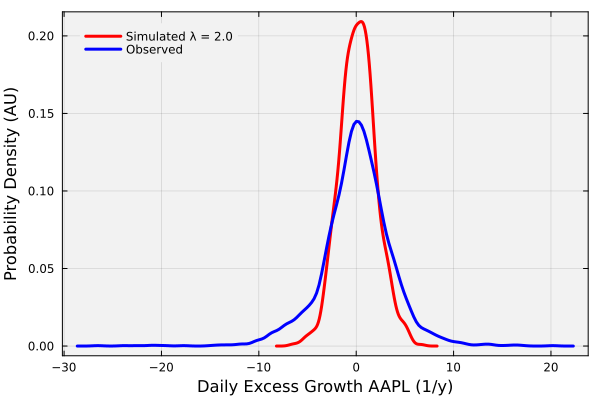

In [17]:
let

    # what is the decsion that are making?
    mytestticker = "AAPL";
    worldmodel = world_model;
    trials = 1000;

    # what is the observed excess return distribution for this ticker?
    Rᵢ = findfirst(x-> x == mytestticker, my_list_of_tickers) |> k-> all_firms_excess_return_matrix[:,k];
    
    # get data from the world model -
    tickers = worldmodel.tickers; # what is my list of tickers?
    parameters = worldmodel.parameters; # single index model parameters
    risk_free_rate = worldmodel.risk_free_rate; # risk-free rate
    Δt = worldmodel.Δt; # time step
    Ḡₘ = worldmodel.Ḡₘ; # mean market growth rate
    buffersize = worldmodel.buffersize; # how many time steps to look ahead
    riskfactors = worldmodel.risk; # risk dictionary
    
    # grab the ticker we are looking at?
    ticker_symbol = mytestticker;
    RF = riskfactors[ticker_symbol]; # risk factor for this ticker

    # get the SIM parameters for this ticker -
    sim_params = parameters[ticker_symbol];
    αᵢ = sim_params.alpha; # asset i intercept
    βᵢ = sim_params.beta; # asset i sensitivity to market
    TV = sim_params.training_variance; # asset i total variance
    σᵢ = sqrt(Δt*TV); # asset i standard deviation

    μ = Array{Float64}(undef, trials);
    for j ∈ 1:trials
        gᵢ = αᵢ/RF + (βᵢ/RF)*(Ḡₘ)+(σᵢ*randn())/RF; # adjusted growth rate for asset i    
        μ[j] = gᵢ;
    end

    density(μ, c=:red, legend = false, lw=3, label="Simulated λ = $(λ)");
    density!(Rᵢ, c=:blue, legend = false, label="Observed", lw=3);
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topleft);
    xlabel!("Daily Excess Growth $(mytestticker) (1/y)", fontsize=18)
    ylabel!("Probability Density (AU)", fontsize=18)

end

The `horizon::Int64` argument controls the number of consecutive time windows of length `buffersize::Int64` used to train the bandit. Let's use all available data, which is `maximum_number_trading_days - buffersize`:

In [18]:
time_sample_results_dict_eps = VLQuantitativeFinancePackage.sample(bandit_model, world_model; 
    horizon = number_of_training_steps);

To visualize how agent beliefs evolve as more data is encountered, specify a value for the `my_ticker_of_interest::String` variable and find its index using [the `findfirst(...)` method](https://docs.julialang.org/en/v1/base/arrays/#Base.findfirst-Tuple{Function,%20Any}):

In [19]:
my_ticker_of_interest = "AAPL"; # specify your own ticker here!
index_of_ticker_to_plot = findfirst(x -> x==my_ticker_of_interest, my_list_of_tickers); 

Unhide the code block to see how we visualized agent belief evolution. 

> __What should we expect to see?__ Initially, the agent holds a uniform belief (yellow line) about the ticker outperforming the risk-free fund, meaning all beliefs are equally probable. As the agent gathers more data, beliefs become more defined. The progressively darker gray lines illustrate this evolution, with the final belief shown by the thick red line.

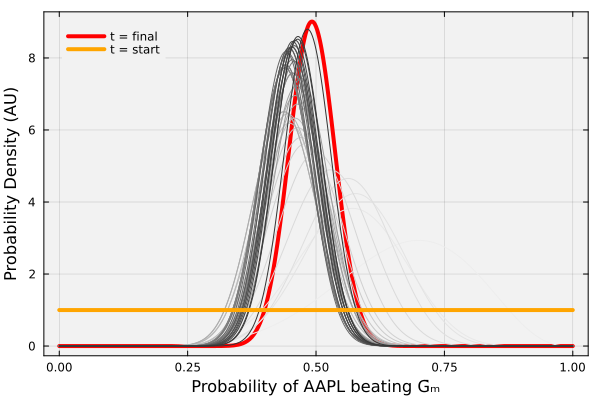

In [20]:
let
    
    # initialize -
    q = plot();
    number_of_trading_periods = length(time_sample_results_dict_eps);
    skip = 250;
    indexes_to_plot = range(2,number_of_trading_periods - 10,step=skip) |> collect;
    N = length(indexes_to_plot);
    C1 = colorant"gray95"
    C2 = colorant"gray20"
    gray_color_array = range(C1, C2, length=N);

    # initial plot -
    d = time_sample_results_dict_eps[number_of_trading_periods][index_of_ticker_to_plot]
    plot(d, label="t = final", c=:red, lw=4, 
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topleft);
    for i ∈ eachindex(indexes_to_plot)
        α = i/N;
        t = indexes_to_plot[i];
        d = time_sample_results_dict_eps[t][index_of_ticker_to_plot]
        plot!(d, label="", c=gray_color_array[i], lw=1)
    end
    d = time_sample_results_dict_eps[1][index_of_ticker_to_plot]
    plot!(d, label="t = start", c=:orange, lw=4)
    xlabel!("Probability of $(my_ticker_of_interest) beating Ḡₘ", fontsize=18)
    ylabel!("Probability Density (AU)", fontsize=18)
    current()
end

___

## Task 3: Run a collection of ticker-picker agents and examine their preferences
In this task, repeat the single-agent analysis with multiple agents by running [the `sample(...)` method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.sample-Tuple{MyEpsilonSamplingBanditModel,%20MyTickerPickerWorldModel}) inside a [for-loop](https://docs.julialang.org/en/v1/base/base/#for). Store results at `trading_day_index::Int64` in the `agent_specific_data::Array{Beta,2}(undef, K, number_of_agents)` array.

The `agent_specific_data` array holds [Beta distributions](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Beta) for each agent at `trading_day_index::Int64` for each ticker. Rows represent tickers, and columns represent agents. Below, we use [the `foreach(...)` iteration pattern](https://docs.julialang.org/en/v1/base/collections/#Base.foreach) to populate the array.

In [21]:
number_of_agents = 500; # how many agents do we want
trading_day_index = number_of_training_steps; # What trading day are we interested in?
agent_specific_data = Array{Beta,2}(undef, K, number_of_agents);

for agent_index ∈ 1:number_of_agents
    
    # sample -
    time_sample_results_dict_eps = VLQuantitativeFinancePackage.sample(bandit_model, world_model; 
        horizon = number_of_training_steps);

    # populate the agent_specific_data array
    foreach(k-> agent_specific_data[k, agent_index] = time_sample_results_dict_eps[trading_day_index][k], 1:K)
end

Let's examine the entry for `agent = 1`, which holds agent perceptions encoded as [Beta distributions](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Beta):

In [22]:
agent_specific_data[:,100][1]

Beta{Float64}(α=263.0, β=230.0)

### Compute the wisdom of the collective
Now that we have agent preferences encoded as Beta distributions, let's develop a consensus belief about which tickers to include in portfolio $\mathcal{P}$. Compute the agent-specific rank of each ticker, where `rank = 1` is best and `rank = K` is worst, and store values in the `preference_rank_array::Array{Int,2}` array.

The challenge is transforming the collective perception, encoded as [Beta distributions](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Beta), into ticker recommendations.

In [23]:
preference_rank_array = Array{Int,2}(undef, number_of_agents, K);
for agent ∈ 1:number_of_agents
        
    # ask an agent about their preference for ticker i -
    experience_distributions = agent_specific_data[:,agent]
    preference_vector = preference(experience_distributions, my_list_of_tickers) .|> x-> trunc(Int64, x) # wow the trunc function is cool!

    # package
    foreach(i -> preference_rank_array[agent, i] = preference_vector[i], 1:K);
end
preference_rank_array

500×30 Matrix{Int64}:
  4   6  30  15  29   3  11  26   1  …  18  22  20   9  28   7  23  21  14
  3  16  20   4  14   8  11  18   5     17  23  24  25   2   9  27  30   1
 29   2  14   4  11   1  10   7  23     20  17  16   8   5  18  19  15   6
 24  25   3  15   8  29   4  18  17      9  13  21  27   7  11   5  26   1
  5  28   8   1  21  11  23   6   4     26  14  22  15  27  29  20  10  24
 18  20  29  22  13   4  25  30   6  …  14  23  19   9  17   8  11  15  24
  1  10  15  27  20   5   9  21  14     23  30  25   8  28   4   2  12  24
  3  11  10   6  28  27  12  26   1     15  23  29  22   5  21  20   8  30
 17   3  25  15   8  28  22  27  21     26  12  10   5  29   1  24  16  23
 11   3  26   6   9  17   4  23  27      8  10  18  30  19   7  13  24  29
  ⋮                   ⋮              ⋱                   ⋮              
 14   3  26  19  28  27  11  20   7      8  29  13  24  25  10   2  15   6
  2   9   7  19  23  15   6  16   3     12  28  18  24   8  10  29  27   4
  4  

#### What's in the preference_rank_array?
The rows of the `preference_rank_array::Array{Int,2}` correspond to agents, while the columns hold each firm's ranking by that agent, with smaller values indicating higher preference. Rankings were calculated [using the `preference(...)` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/bandits/#VLQuantitativeFinancePackage.preference), which takes agent beliefs encoded as [Beta distributions](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Beta) and returns ordinal rankings.

> __Strategy:__ Let's count how many times each ticker appears in the top M across all agents, then normalize to estimate the probability of top-M ranking using a [for-loop](https://docs.julialang.org/en/v1/base/base/#for). First, set a value for `M::Int64`, the number of top firms to consider. Store probabilities in the `probability_top_dictionary::Dict{String, Float64}`.

The code makes heavy use of [the pipe operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping) to condense operations.

In [24]:
M = 15; # look for top M firms
probability_top_dictionary = Dict{String,Float64}();
for i ∈ eachindex(my_list_of_tickers)
    probability = findall(x-> x ≤ M, preference_rank_array[:,i]) |> x -> length(x) |> x-> x/number_of_agents; # compute probability
    my_list_of_tickers[i] |> ticker -> probability_top_dictionary[ticker] = probability; # store probability
end

Build a preference table over the population of agents.
The `probability_top_dictionary::Dict{String, Float64}` holds the probability each ticker is ranked in the top M.

Unhide the code block to see how we constructed the preference table using [the `ordinalrank(...)` function from StatsBase.jl](https://github.com/JuliaStats/StatsBase.jl) and [PrettyTables.jl](https://github.com/ronisbr/PrettyTables.jl).
* The preference table shows which tickers are most frequently ranked in the top M across all agents. Tickers with higher probabilities (closer to 1.0) are more consistently selected by the agent population.
*  __Note__: Because the problem is stochastic, results will vary between runs. Increasing the number of agents `N::Int64` improves convergence and stability at the expense of computational efficiency.
  
Let's think more deeply about these results:
* Tickers with high preference (small ranks and high probabilities) are more likely to beat a risk-free investment, while low-ranked tickers may not outperform over repeated `buffersize::Int64` investment periods. 
* However, we haven't considered volatility or alternative investment choices, e.g., using `SPY` versus the risk-free fund. We'll address these questions in the project and advanced examples.

Ultimately, it's unclear how to construct portfolios from these preferences for risk-blind or risk-aware agents. We'll explore this question using out-of-sample data in an advanced example.

In [25]:
let
    # initialize 
    df = DataFrame();
    tmp = Array{Float64,1}();

    # compute the ordinal rank of the sorted list of tickers
    my_sorted_tickers = my_list_of_tickers |> sort;
    foreach(ticker -> push!(tmp, probability_top_dictionary[ticker]), my_sorted_tickers)
    ordinal_rank = ordinalrank(tmp, rev=true); # function exported by StatsBase.jl
    
    # populate rows in the df -
    for i ∈ eachindex(my_sorted_tickers)
        ticker_value = my_sorted_tickers[i];    
        freq_value = probability_top_dictionary[ticker_value];
        row_df = (
            ticker = ticker_value,
            probability = freq_value,
            rank = ordinal_rank[i]
        );
        push!(df, row_df);
    end
    
    pretty_table(
        df;
        fit_table_in_display_vertically = false,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 -------- ------------- -------
  ticker   probability    rank 
  String       Float64   Int64 
 -------- ------------- -------
    AAPL         0.616       9
     AMD         0.486      15
     BAC          0.36      23
       C          0.21      30
   CMCSA         0.456      18
     ECL          0.38      22
      GS         0.418      21
    INTC          0.31      27
     JNJ         0.486      16
     JPM          0.44      19
      KR         0.638       7
     LLY          0.71       2
     MET         0.308      28
     MMM          0.36      24
     MRK         0.548      12
    MSFT          0.66       5
      MU         0.354      25
    NFLX         0.624       8
    NVDA         0.672       4
     OXY         0.302      29
     PEP           0.5      14
     PFE          0.42      20
      PG         0.596      10
     QQQ         0.596      11
     SPY         0.896       1
     SRE          0.53      13
    TSLA         0.474      17
     UNH         0.648       6
    

___

## Summary
This example demonstrates how to apply ε-greedy bandit algorithms to ticker selection by training multiple agents on historical market data and aggregating their preferences.

> __Key Takeaways:__
> 
> * __Bandit models learn ticker preferences through binary reward feedback:__ Each ticker-picker agent updates Beta distributions based on success (ticker outperforms risk-free rate) or failure (ticker underperforms) over rolling evaluation windows. The ε parameter controls the fraction of random exploration steps versus exploitation of current beliefs.
> * __Agent beliefs evolve from uniform to data-informed distributions:__ Initial uniform Beta distributions represent no preference among tickers. As agents sample more data, their beliefs concentrate around specific probability values, with final distributions showing clear preferences for tickers that consistently outperform the risk-free benchmark.
> * __Collective preferences emerge from aggregating independent agent rankings:__ Computing the frequency of tickers appearing in top-M groups across multiple agents produces probability estimates for ticker quality. Ordinal ranking of these probabilities identifies consensus choices, though volatility and alternative benchmarks remain unaddressed in this framework.

Bandit algorithms provide a framework for sequential decision-making under uncertainty in financial ticker selection.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___